# Hand Gesture Recognition — EDA & Report Analysis

**Track B: Open/Public Dataset (HGAG-DATA)**  
This notebook produces all tables, figures, and statistics needed for the Milestone 2 PDF report (D1).  
It uses the same data loading pipeline as `train_baseline.ipynb` for consistency.

---
## 0. Setup & Library Versions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 150, "font.size": 10})

# ---------- version info ----------
print(f"Python      : {sys.version}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
import sklearn; print(f"Scikit-learn: {sklearn.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Seaborn     : {sns.__version__}")

Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy       : 2.0.2
Pandas      : 2.2.2
Scikit-learn: 1.6.1
Matplotlib  : 3.10.0
Seaborn     : 0.13.2


In [ ]:
import shutil

---
## 1. Data Loading (aligned with train_baseline.ipynb)

In [ ]:
import os
import shutil

ZIP_PATH = "/content/drive/MyDrive/TinyML-Project/dataset.zip"
LOCAL_EXTRACT_ROOT = "/content/tinyml_data"

if os.path.exists(LOCAL_EXTRACT_ROOT):
    print("Removing old local extracted dataset...")
    shutil.rmtree(LOCAL_EXTRACT_ROOT)

os.makedirs(LOCAL_EXTRACT_ROOT, exist_ok=True)

print("Unzipping dataset from Drive ZIP to local runtime...")
!unzip -q "{ZIP_PATH}" -d "{LOCAL_EXTRACT_ROOT}"
print("Unzip complete.")

Unzipping dataset from Drive ZIP to local runtime...
Unzip complete.


In [ ]:
import os
import numpy as np
import pandas as pd

candidates = [
    "/content/tinyml_data/data",
    "/content/tinyml_data/HGAG-DATA",
    "/content/tinyml_data"
]

DATA_ROOT = None
for c in candidates:
    if os.path.exists(os.path.join(c, "train")) and os.path.exists(os.path.join(c, "val")):
        DATA_ROOT = c
        break

if DATA_ROOT is None:
    raise FileNotFoundError("Could not find dataset root containing train/val/test after unzip.")

TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
TEST_DIR  = os.path.join(DATA_ROOT, "test")

CHANNELS = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
CHANNEL_FILES = [f"{ch}_data.csv" for ch in CHANNELS]

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN exists:", os.path.exists(TRAIN_DIR))
print("VAL exists  :", os.path.exists(VAL_DIR))
print("TEST exists :", os.path.exists(TEST_DIR))

GESTURE_CLASSES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

NUM_CLASSES = len(GESTURE_CLASSES)
print(f"Gesture classes ({NUM_CLASSES}): {GESTURE_CLASSES}")

DATA_ROOT: /content/tinyml_data/data
TRAIN exists: True
VAL exists  : True
TEST exists : True
Gesture classes (11): ['Clapping', 'Coin Flipping', 'Finger Snapping', 'Fist Making', 'Horizontal Wrist Extension', 'Index Finger Flick', 'Index Thumb Tap', 'Shooting', 'Thumb Up', 'Wrist Extension', 'Wrist Flexion']


In [ ]:
def load_split_detailed(split_dir, gesture_classes, channel_files):
    """Load data and also track which subject each trial came from."""
    X_list, y_list, subj_list = [], [], []

    for gesture_idx, gesture in enumerate(gesture_classes):
        gesture_dir = os.path.join(split_dir, gesture)
        if not os.path.isdir(gesture_dir):
            continue

        for subject in sorted(os.listdir(gesture_dir)):
            subject_dir = os.path.join(gesture_dir, subject, ".csv")
            if not os.path.isdir(subject_dir):
                continue

            channel_data = []
            valid_subject = True

            for ch_file in channel_files:
                filepath = os.path.join(subject_dir, ch_file)

                if not os.path.exists(filepath):
                    print(f"Missing file: {filepath}")
                    valid_subject = False
                    break

                data = np.loadtxt(filepath, delimiter=",", dtype=np.float32)

                if data.ndim == 1:
                    data = data.reshape(1, -1)

                channel_data.append(data)

            if not valid_subject:
                continue

            features = np.concatenate(channel_data, axis=1)
            n_trials = features.shape[0]

            X_list.append(features)
            y_list.extend([gesture_idx] * n_trials)
            subj_list.extend([subject] * n_trials)

    return np.vstack(X_list), np.array(y_list), np.array(subj_list)

In [ ]:
X_train, y_train, subj_train = load_split_detailed(TRAIN_DIR, GESTURE_CLASSES, CHANNEL_FILES)
X_val,   y_val,   subj_val   = load_split_detailed(VAL_DIR,   GESTURE_CLASSES, CHANNEL_FILES)
X_test,  y_test,  subj_test  = load_split_detailed(TEST_DIR,  GESTURE_CLASSES, CHANNEL_FILES)

print(f"Train : X={X_train.shape}, y={y_train.shape}")
print(f"Val   : X={X_val.shape}, y={y_val.shape}")
print(f"Test  : X={X_test.shape}, y={y_test.shape}")
print(f"Feature dimension: {X_train.shape[1]}")

Train : X=(17050, 1500), y=(17050,)
Val   : X=(3298, 1500), y=(3298,)
Test  : X=(3300, 1500), y=(3300,)
Feature dimension: 1500


In [ ]:
CACHE_DIR = "/content/drive/MyDrive/TinyML-Project/cache_arrays"
os.makedirs(CACHE_DIR, exist_ok=True)

np.save(os.path.join(CACHE_DIR, "X_train.npy"), X_train)
np.save(os.path.join(CACHE_DIR, "y_train.npy"), y_train)
np.save(os.path.join(CACHE_DIR, "X_val.npy"), X_val)
np.save(os.path.join(CACHE_DIR, "y_val.npy"), y_val)
np.save(os.path.join(CACHE_DIR, "X_test.npy"), X_test)
np.save(os.path.join(CACHE_DIR, "y_test.npy"), y_test)

print("Saved cached arrays to Drive.")

Saved cached arrays to Drive.


In [ ]:
CACHE_DIR = "/content/drive/MyDrive/TinyML-Project/cache_arrays"

X_train = np.load(os.path.join(CACHE_DIR, "X_train.npy"))
y_train = np.load(os.path.join(CACHE_DIR, "y_train.npy"))
X_val   = np.load(os.path.join(CACHE_DIR, "X_val.npy"))
y_val   = np.load(os.path.join(CACHE_DIR, "y_val.npy"))
X_test  = np.load(os.path.join(CACHE_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(CACHE_DIR, "y_test.npy"))

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)

(17050, 1500) (17050,) (3298, 1500) (3298,) (3300, 1500) (3300,)


---
## 2. R1 — Dataset Description: Class Distribution Table

This produces the **per-class sample counts** table required in R1 and R2.

In [ ]:
# === per-class distribution table ===
train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts   = pd.Series(y_val).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

class_distribution_df = pd.DataFrame({
    "Class Index": range(NUM_CLASSES),
    "Gesture Class": GESTURE_CLASSES,
    "Train Samples": train_counts.reindex(range(NUM_CLASSES), fill_value=0).values,
    "Val Samples": val_counts.reindex(range(NUM_CLASSES), fill_value=0).values,
    "Test Samples": test_counts.reindex(range(NUM_CLASSES), fill_value=0).values,
})

class_distribution_df["Total Samples"] = (
    class_distribution_df["Train Samples"] +
    class_distribution_df["Val Samples"] +
    class_distribution_df["Test Samples"]
)

class_distribution_df

,Class Index,Gesture Class,Train Samples,Val Samples,Test Samples,Total Samples
0,0,Clapping,1550,300,300,2150
1,1,Coin Flipping,1550,300,300,2150
2,2,Finger Snapping,1550,300,300,2150
3,3,Fist Making,1550,298,300,2148
4,4,Horizontal Wrist Extension,1550,300,300,2150
5,5,Index Finger Flick,1550,300,300,2150
6,6,Index Thumb Tap,1550,300,300,2150
7,7,Shooting,1550,300,300,2150
8,8,Thumb Up,1550,300,300,2150
9,9,Wrist Extension,1550,300,300,2150


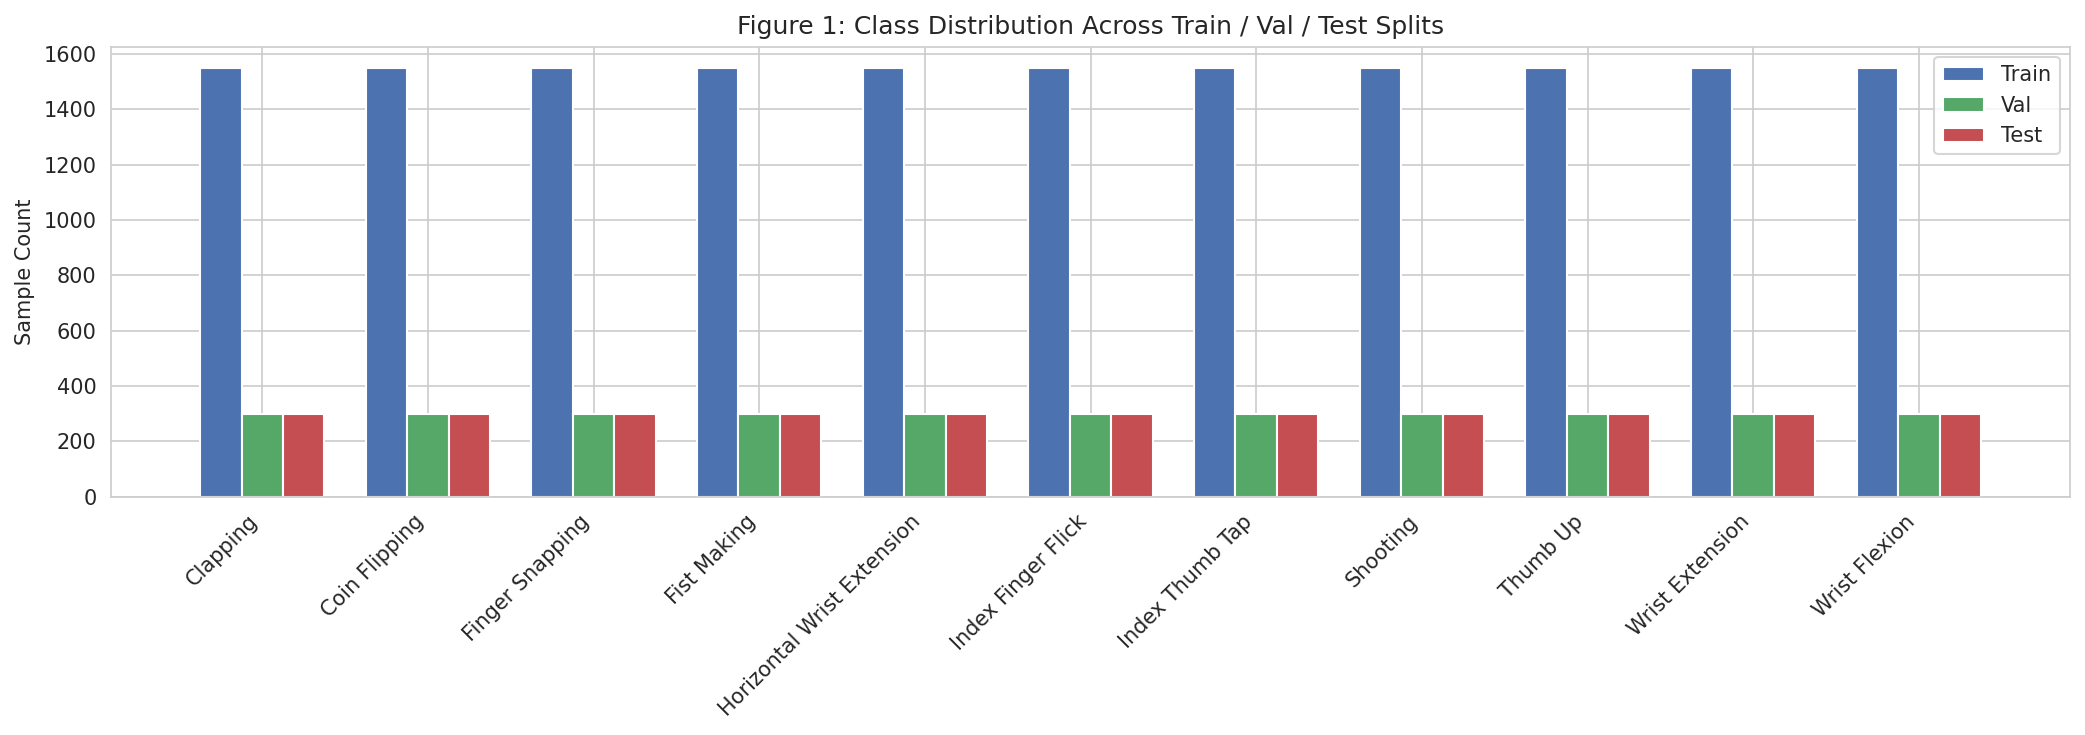

In [ ]:
# ── visual: class distribution bar chart ──
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(NUM_CLASSES)
width = 0.25

plot_df = class_distribution_df.copy()

# bars
ax.bar(x - width, plot_df["Train Samples"], width, label="Train", color="#4c72b0")
ax.bar(x,         plot_df["Val Samples"],   width, label="Val",   color="#55a868")
ax.bar(x + width, plot_df["Test Samples"],  width, label="Test",  color="#c44e52")

# labels
ax.set_xticks(x)
ax.set_xticklabels(GESTURE_CLASSES, rotation=45, ha="right")

ax.set_ylabel("Sample Count")
ax.set_title("Figure 1: Class Distribution Across Train / Val / Test Splits")
ax.legend()

plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Subject (User) Distribution Across Splits

Important for R2 (split method) and understanding data leakage risk.

In [ ]:
# ── which subjects are in each split? ──
train_subjects = set(subj_train)
val_subjects   = set(subj_val)
test_subjects  = set(subj_test)

print(f"Train subjects ({len(train_subjects)}): {sorted(train_subjects)}")
print(f"Val   subjects ({len(val_subjects)}):   {sorted(val_subjects)}")
print(f"Test  subjects ({len(test_subjects)}):  {sorted(test_subjects)}")

# check for overlap
train_val_overlap  = train_subjects & val_subjects
train_test_overlap = train_subjects & test_subjects
val_test_overlap   = val_subjects & test_subjects

print(f"\nTrain ∩ Val  overlap: {train_val_overlap if train_val_overlap else 'NONE (good)'}")
print(f"Train ∩ Test overlap: {train_test_overlap if train_test_overlap else 'NONE (good)'}")
print(f"Val   ∩ Test overlap: {val_test_overlap if val_test_overlap else 'NONE (good)'}")

if not (train_val_overlap or train_test_overlap or val_test_overlap):
    print("\n✅ Split is PER-SUBJECT — no data leakage between splits.")
else:
    print("\n⚠️  Subject overlap detected — investigate potential leakage.")

Train subjects (31): [np.str_('Subject_1'), np.str_('Subject_10'), np.str_('Subject_12'), np.str_('Subject_13'), np.str_('Subject_14'), np.str_('Subject_16'), np.str_('Subject_17'), np.str_('Subject_18'), np.str_('Subject_2'), np.str_('Subject_20'), np.str_('Subject_22'), np.str_('Subject_25'), np.str_('Subject_26'), np.str_('Subject_27'), np.str_('Subject_28'), np.str_('Subject_30'), np.str_('Subject_31'), np.str_('Subject_32'), np.str_('Subject_33'), np.str_('Subject_35'), np.str_('Subject_37'), np.str_('Subject_38'), np.str_('Subject_4'), np.str_('Subject_40'), np.str_('Subject_41'), np.str_('Subject_42'), np.str_('Subject_43'), np.str_('Subject_5'), np.str_('Subject_6'), np.str_('Subject_7'), np.str_('Subject_9')]
Val   subjects (6):   [np.str_('Subject_11'), np.str_('Subject_23'), np.str_('Subject_24'), np.str_('Subject_3'), np.str_('Subject_34'), np.str_('Subject_36')]
Test  subjects (6):  [np.str_('Subject_15'), np.str_('Subject_19'), np.str_('Subject_21'), np.str_('Subject_29')

In [ ]:
# ── trials per subject per split ──
for split_name, subj_arr, y_arr in [("Train", subj_train, y_train),
                                     ("Val",   subj_val,   y_val),
                                     ("Test",  subj_test,  y_test)]:
    print(f"\n--- {split_name} ---")
    df_tmp = pd.DataFrame({"subject": subj_arr, "gesture": y_arr})
    pivot = df_tmp.groupby(["subject", "gesture"]).size().unstack(fill_value=0)
    print(pivot.to_string())


--- Train ---
gesture     0   1   2   3   4   5   6   7   8   9   10
subject                                               
Subject_1   50  50  50  50  50  50  50  50  50  50  50
Subject_10  50  50  50  50  50  50  50  50  50  50  50
Subject_12  50  50  50  50  50  50  50  50  50  50  50
Subject_13  50  50  50  50  50  50  50  50  50  50  50
Subject_14  50  50  50  50  50  50  50  50  50  50  50
Subject_16  50  50  50  50  50  50  50  50  50  50  50
Subject_17  50  50  50  50  50  50  50  50  50  50  50
Subject_18  50  50  50  50  50  50  50  50  50  50  50
Subject_2   50  50  50  50  50  50  50  50  50  50  50
Subject_20  50  50  50  50  50  50  50  50  50  50  50
Subject_22  50  50  50  50  50  50  50  50  50  50  50
Subject_25  50  50  50  50  50  50  50  50  50  50  50
Subject_26  50  50  50  50  50  50  50  50  50  50  50
Subject_27  50  50  50  50  50  50  50  50  50  50  50
Subject_28  50  50  50  50  50  50  50  50  50  50  50
Subject_30  50  50  50  50  50  50  50  50  50  50

---
## 4. R3 — Feature Space Analysis (DWT Coefficients)

Understanding the 1500-dimensional DWT feature space: per-channel statistics, distributions, and correlations.

In [ ]:
# ── per-channel basic statistics ──
n_coeffs = X_train.shape[1] // len(CHANNELS)  # 250 per channel

print(f"DWT coefficients per channel: {n_coeffs}")
print(f"Total features: {len(CHANNELS)} × {n_coeffs} = {X_train.shape[1]}\n")

channel_stats = []
for idx, ch in enumerate(CHANNELS):
    start = idx * n_coeffs
    end   = start + n_coeffs
    ch_data = X_train[:, start:end]
    channel_stats.append({
        "Channel": ch,
        "Mean":    ch_data.mean(),
        "Std":     ch_data.std(),
        "Min":     ch_data.min(),
        "Max":     ch_data.max(),
        "Median":  np.median(ch_data),
        "Zeros%":  (ch_data == 0).mean() * 100
    })

stats_df = pd.DataFrame(channel_stats)
print("Per-channel statistics (training set):")
print(stats_df.to_string(index=False, float_format="{:.4f}".format))

DWT coefficients per channel: 250
Total features: 6 × 250 = 1500

Per-channel statistics (training set):
Channel    Mean    Std      Min      Max  Median  Zeros%
accel_x  0.0064 1.0778 -53.2863  28.0278 -0.0001  0.0059
accel_y -0.0030 1.3787 -51.1140  41.2944  0.0000  0.0059
accel_z -0.0134 1.8712 -99.1566 103.5284  0.0001  0.0059
 gyro_x  0.0000 0.3730  -6.9901   4.7497 -0.0000  0.0117
 gyro_y -0.0000 0.1258  -3.7599   2.6631  0.0000  0.0059
 gyro_z  0.0000 0.0879  -2.6984   3.1398  0.0000  0.0059


/tmp/ipykernel_484/3050407279.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=GESTURE_CLASSES, patch_artist=True)
/tmp/ipykernel_484/3050407279.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=GESTURE_CLASSES, patch_artist=True)
/tmp/ipykernel_484/3050407279.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=GESTURE_CLASSES, patch_artist=True)
/tmp/ipykernel_484/3050407279.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9

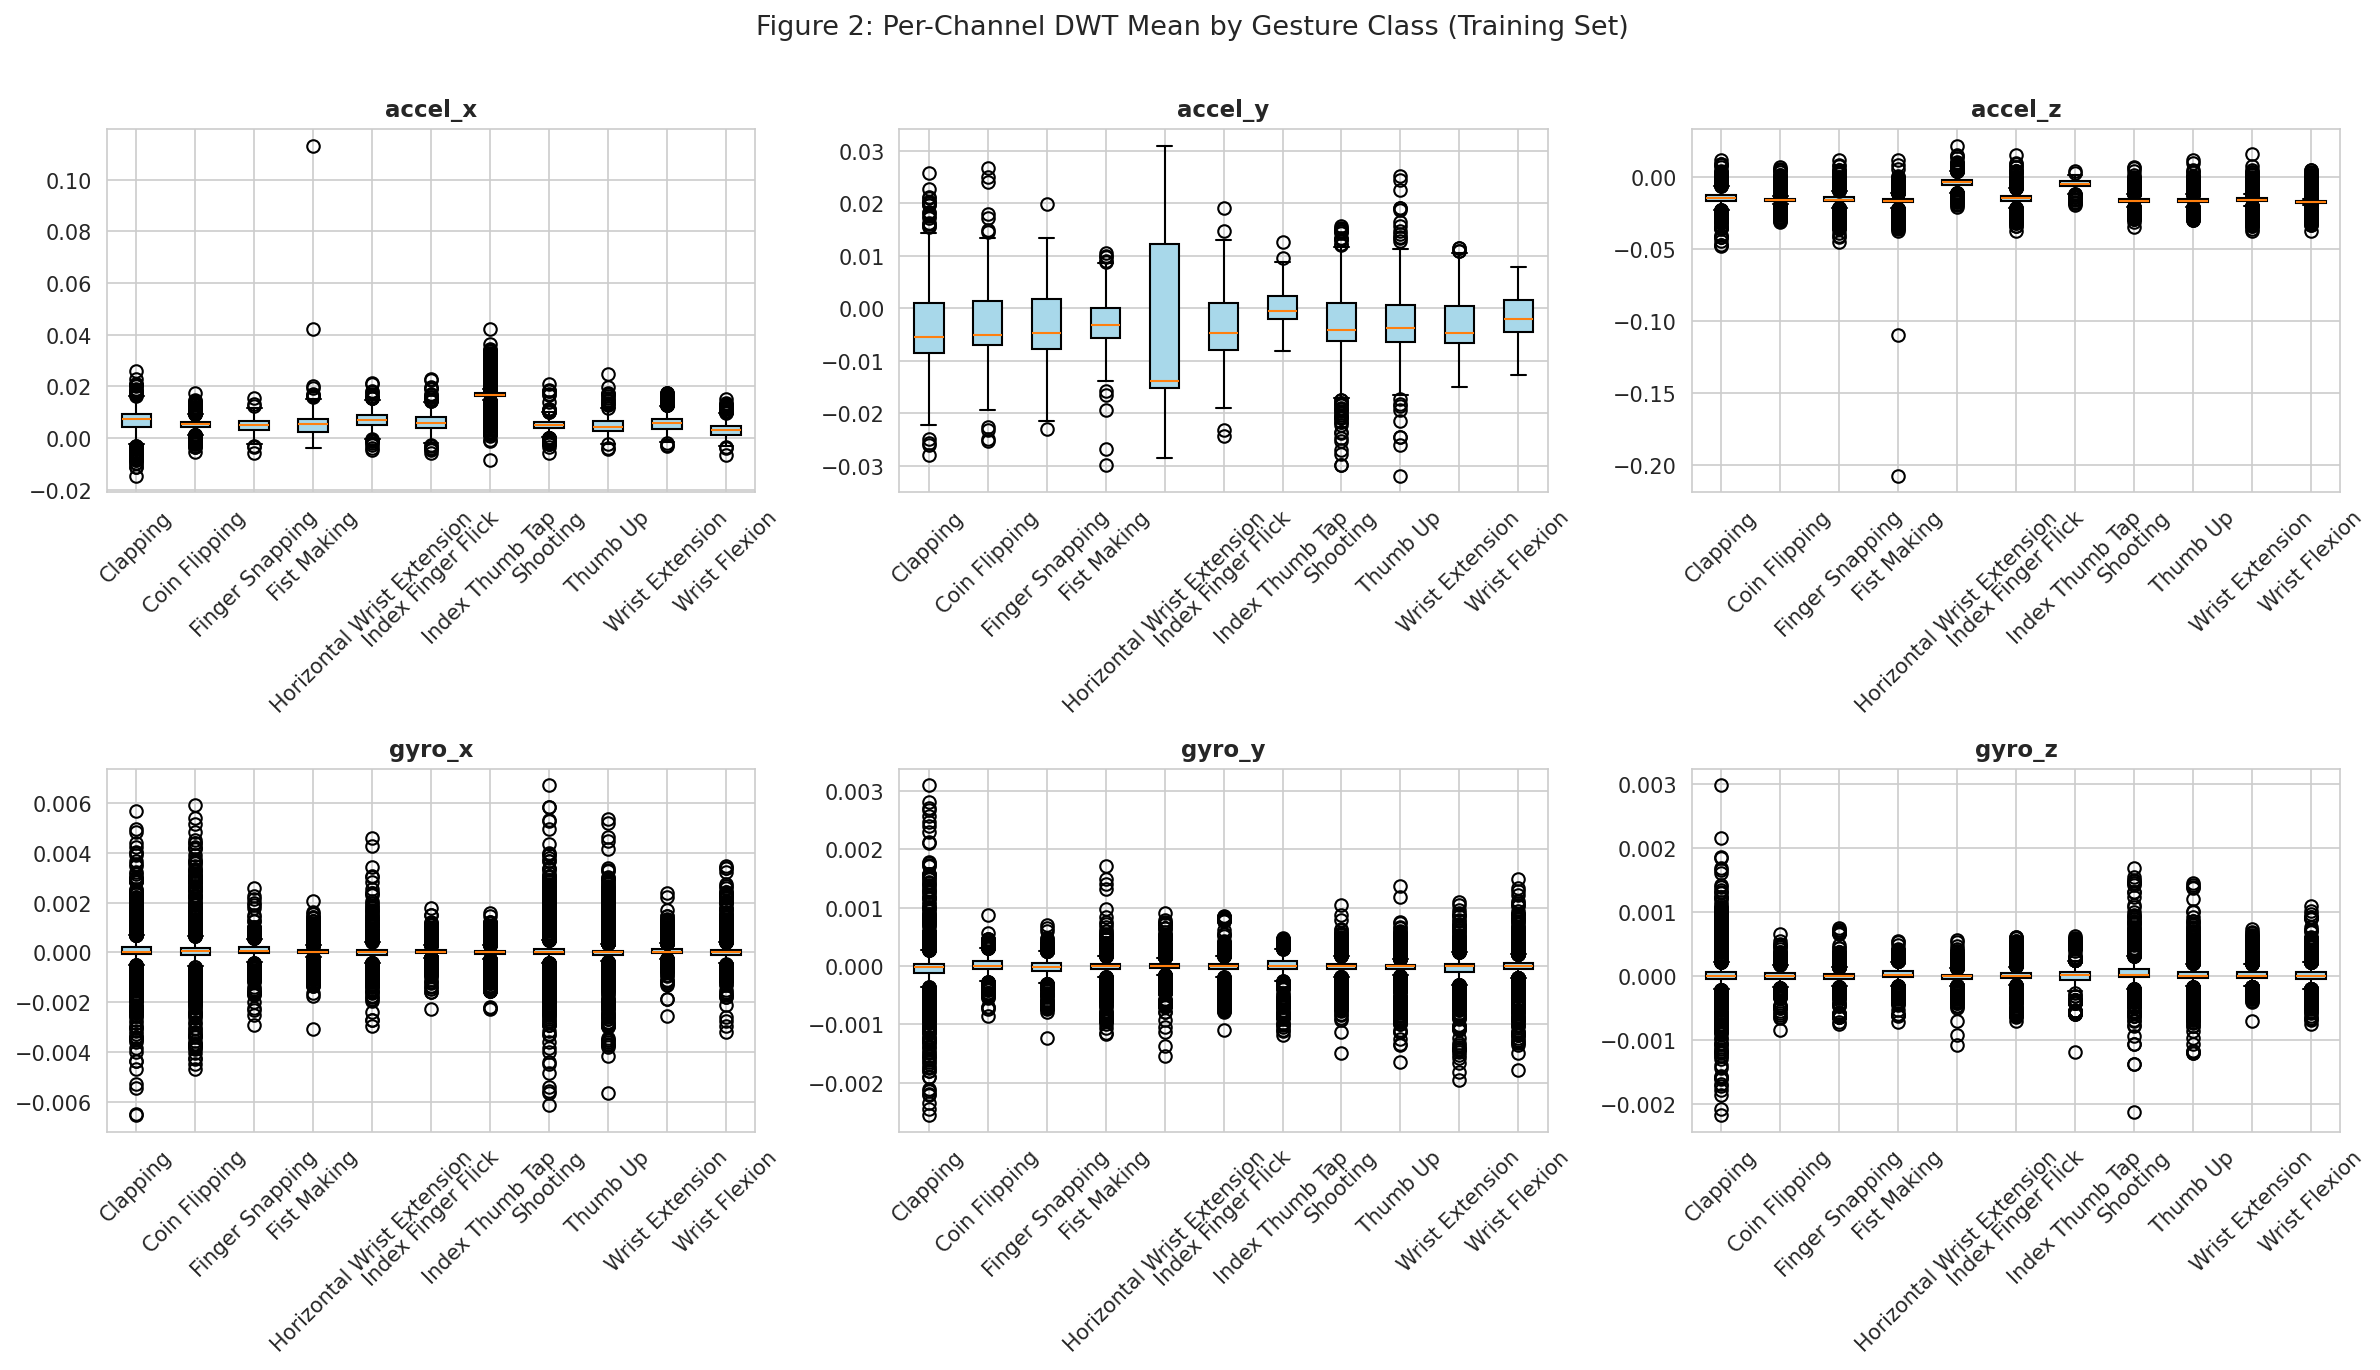

In [ ]:
# ── per-channel distribution boxplots (mean across DWT coeffs per trial) ──
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for idx, (ch, ax) in enumerate(zip(CHANNELS, axes.flat)):
    start = idx * n_coeffs
    end   = start + n_coeffs
    # compute per-trial mean for this channel
    ch_means = X_train[:, start:end].mean(axis=1)
    # group by gesture class
    data_by_class = [ch_means[y_train == i] for i in range(NUM_CLASSES)]
    bp = ax.boxplot(data_by_class, labels=GESTURE_CLASSES, patch_artist=True)
    ax.set_title(ch, fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    for patch in bp["boxes"]:
        patch.set_facecolor("#a8d8ea")

fig.suptitle("Figure 2: Per-Channel DWT Mean by Gesture Class (Training Set)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig2_channel_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

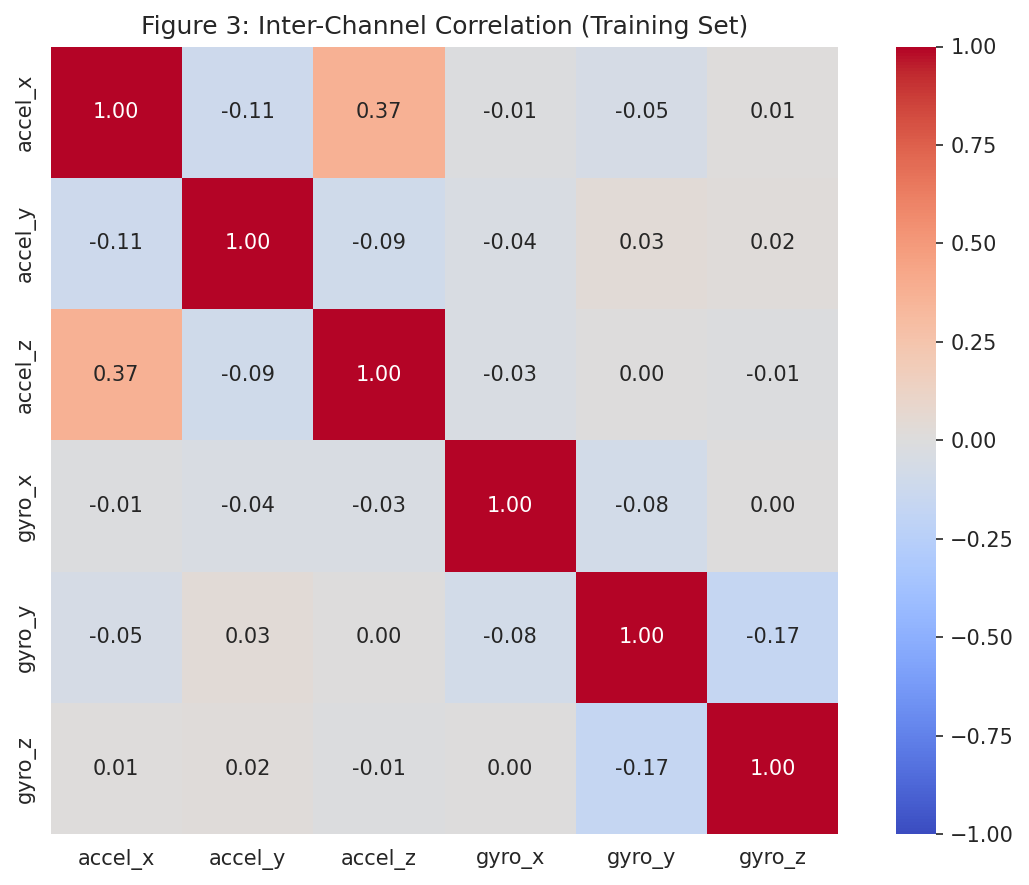

In [ ]:
# ── inter-channel correlation (using per-trial channel means) ──
channel_means_matrix = np.zeros((len(X_train), len(CHANNELS)))
for idx, ch in enumerate(CHANNELS):
    start = idx * n_coeffs
    end   = start + n_coeffs
    channel_means_matrix[:, idx] = X_train[:, start:end].mean(axis=1)

corr_df = pd.DataFrame(channel_means_matrix, columns=CHANNELS).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title("Figure 3: Inter-Channel Correlation (Training Set)")
plt.tight_layout()
plt.savefig("fig3_channel_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. R3 — Normalization Verification

Confirm that StandardScaler is fit on train only.

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("After StandardScaler (fit on TRAIN only):")
print(f"  Train — mean: {X_train_sc.mean():.6f}, std: {X_train_sc.std():.6f}")
print(f"  Val   — mean: {X_val_sc.mean():.6f}, std: {X_val_sc.std():.6f}")
print(f"  Test  — mean: {X_test_sc.mean():.6f}, std: {X_test_sc.std():.6f}")
print("\n✅ Normalization uses training-set statistics only.")

After StandardScaler (fit on TRAIN only):
  Train — mean: 0.000000, std: 1.000000
  Val   — mean: 0.000315, std: 0.968346
  Test  — mean: -0.000047, std: 0.840683

✅ Normalization uses training-set statistics only.


---
## 6. R2 — Data Card Values

Auto-computed values to fill into the Data Card table.

In [ ]:
total_samples = len(y_train) + len(y_val) + len(y_test)
all_subjects  = sorted(train_subjects | val_subjects | test_subjects)

print("=" * 55)
print("DATA CARD VALUES  (copy into report R2)")
print("=" * 55)
print(f"Task type                : Classification (11-class hand gesture recognition)")
print(f"Number of classes         : {NUM_CLASSES}")
print(f"Classes                   : {', '.join(GESTURE_CLASSES)}")
print(f"Sensor(s) & sampling rate : 3-axis accelerometer + 3-axis gyroscope")
print(f"                            (check HGAG paper for exact Hz)")
print(f"Features extracted        : DWT coefficients, {n_coeffs} per channel × 6 channels = {X_train.shape[1]}")
print(f"Total samples             : {total_samples}")
print(f"Train / Val / Test split  : {len(y_train)} / {len(y_val)} / {len(y_test)} "
      f"({len(y_train)/total_samples*100:.0f}% / {len(y_val)/total_samples*100:.0f}% / {len(y_test)/total_samples*100:.0f}%)")
print(f"Split method              : Per-subject (no subject overlap between splits)"
      if not (train_val_overlap or train_test_overlap or val_test_overlap)
      else f"Split method              : CHECK — overlap detected")
print(f"Number of subjects        : {len(all_subjects)}")
print(f"Subject IDs               : {all_subjects}")
print(f"Known limitations         : [fill in: single environment, specific sensor hardware, etc.]")
print()
print("--- Track B additional fields ---")
print(f"Dataset name              : HGAG — Hand Gesture Accelerometer and Gyroscope Dataset")
print(f"URL / citation            : [fill in exact URL/DOI]")
print(f"License                   : [fill in]")
print(f"Original recording equip. : [fill in from HGAG paper]")
print(f"Domain gap vs Arduino     : [fill in: sensor model, sampling rate diff, noise floor diff]")
print(f"Arduino collection plan   : [fill in: when, sensor config, how many samples, users/envs]")

DATA CARD VALUES  (copy into report R2)
Task type                : Classification (11-class hand gesture recognition)
Number of classes         : 11
Classes                   : Clapping, Coin Flipping, Finger Snapping, Fist Making, Horizontal Wrist Extension, Index Finger Flick, Index Thumb Tap, Shooting, Thumb Up, Wrist Extension, Wrist Flexion
Sensor(s) & sampling rate : 3-axis accelerometer + 3-axis gyroscope
                            (check HGAG paper for exact Hz)
Features extracted        : DWT coefficients, 250 per channel × 6 channels = 1500
Total samples             : 23648
Train / Val / Test split  : 17050 / 3298 / 3300 (72% / 14% / 14%)
Split method              : Per-subject (no subject overlap between splits)
Number of subjects        : 43
Subject IDs               : [np.str_('Subject_1'), np.str_('Subject_10'), np.str_('Subject_11'), np.str_('Subject_12'), np.str_('Subject_13'), np.str_('Subject_14'), np.str_('Subject_15'), np.str_('Subject_16'), np.str_('Subject_17'), 

---
## 7. Class Separability — Pairwise Visualization

Dimensionality reduction to visualize class overlap (for error analysis in R6).

PCA explained variance: PC1=0.042, PC2=0.021, Total=0.063


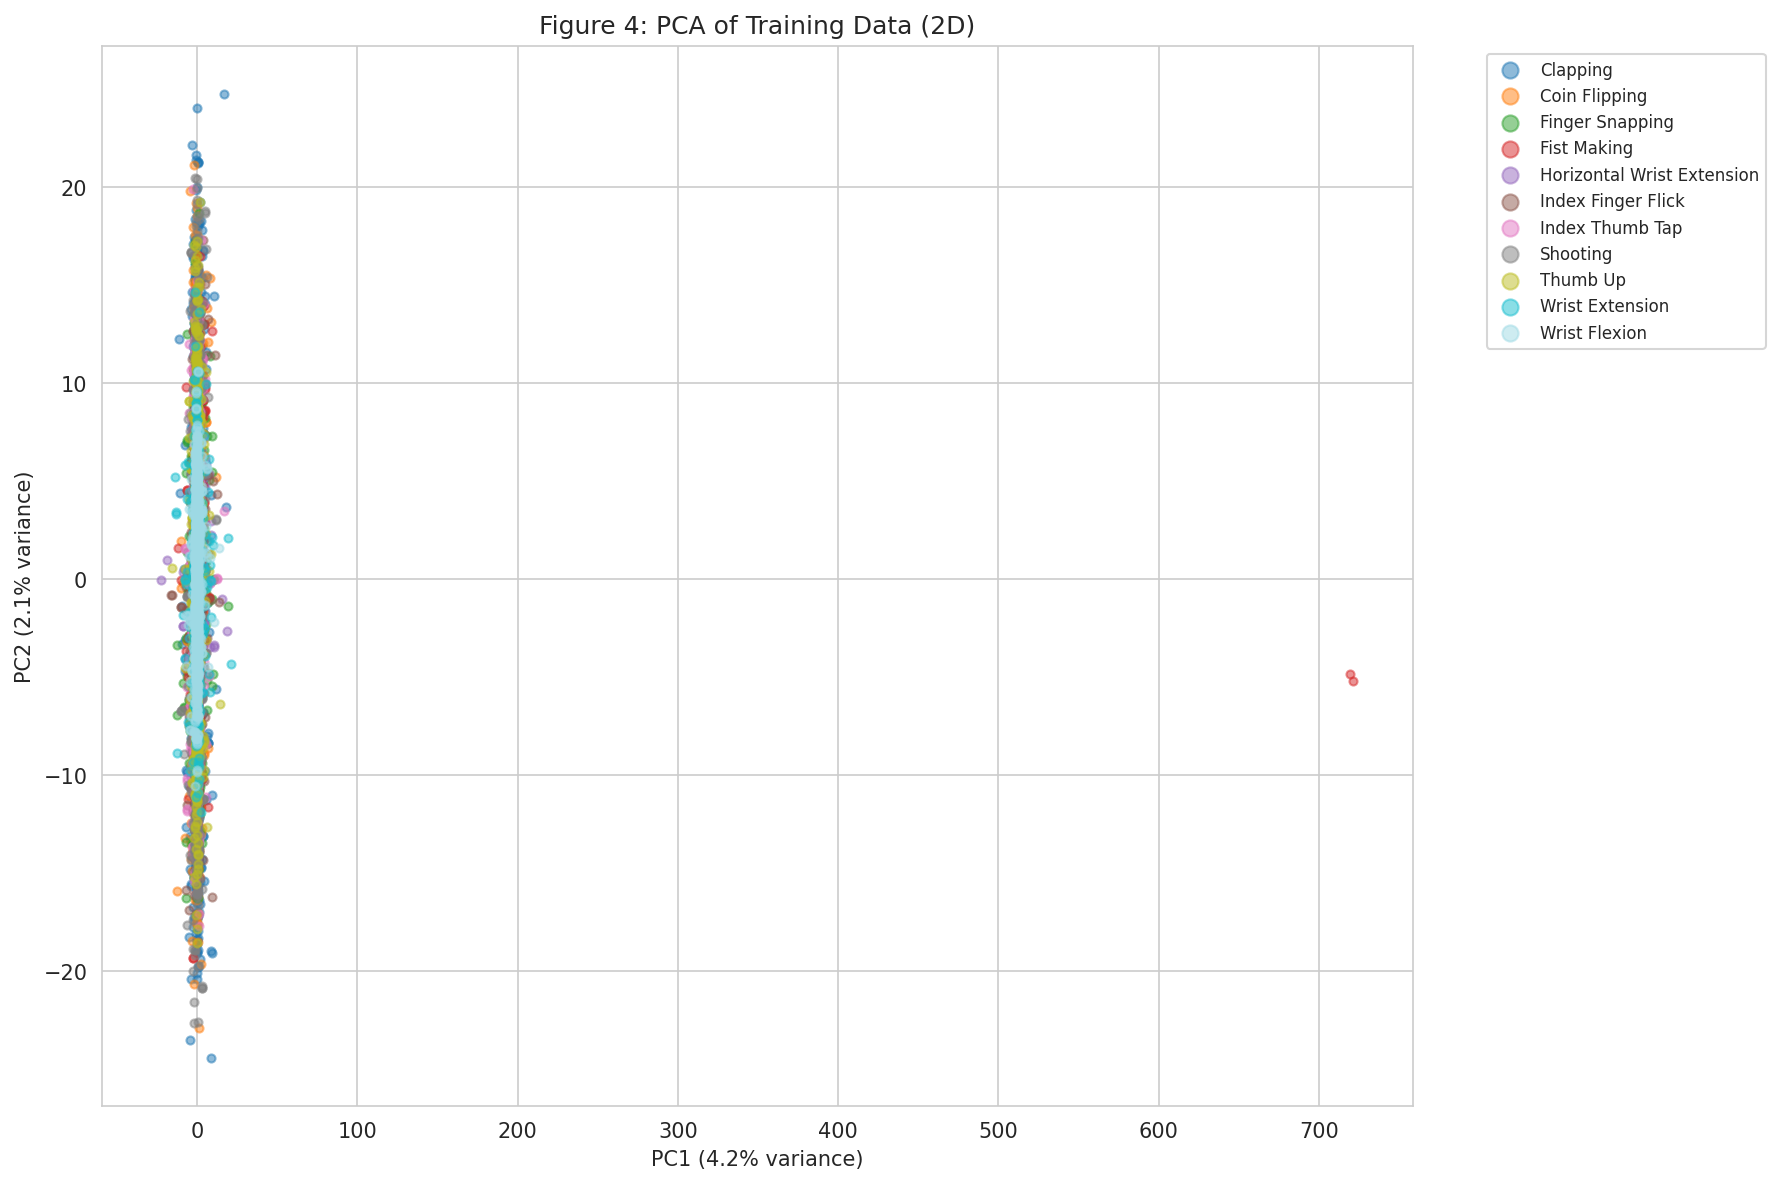

In [ ]:
from sklearn.decomposition import PCA

# PCA on scaled training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_sc)

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"Total={sum(pca.explained_variance_ratio_[:2]):.3f}")

fig, ax = plt.subplots(figsize=(12, 8))
scatter_colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))

for idx, gesture in enumerate(GESTURE_CLASSES):
    mask = (y_train == idx)   # <-- fixed
    ax.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        alpha=0.5,
        s=15,
        label=gesture,
        color=scatter_colors[idx]
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Figure 4: PCA of Training Data (2D)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig("fig4_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

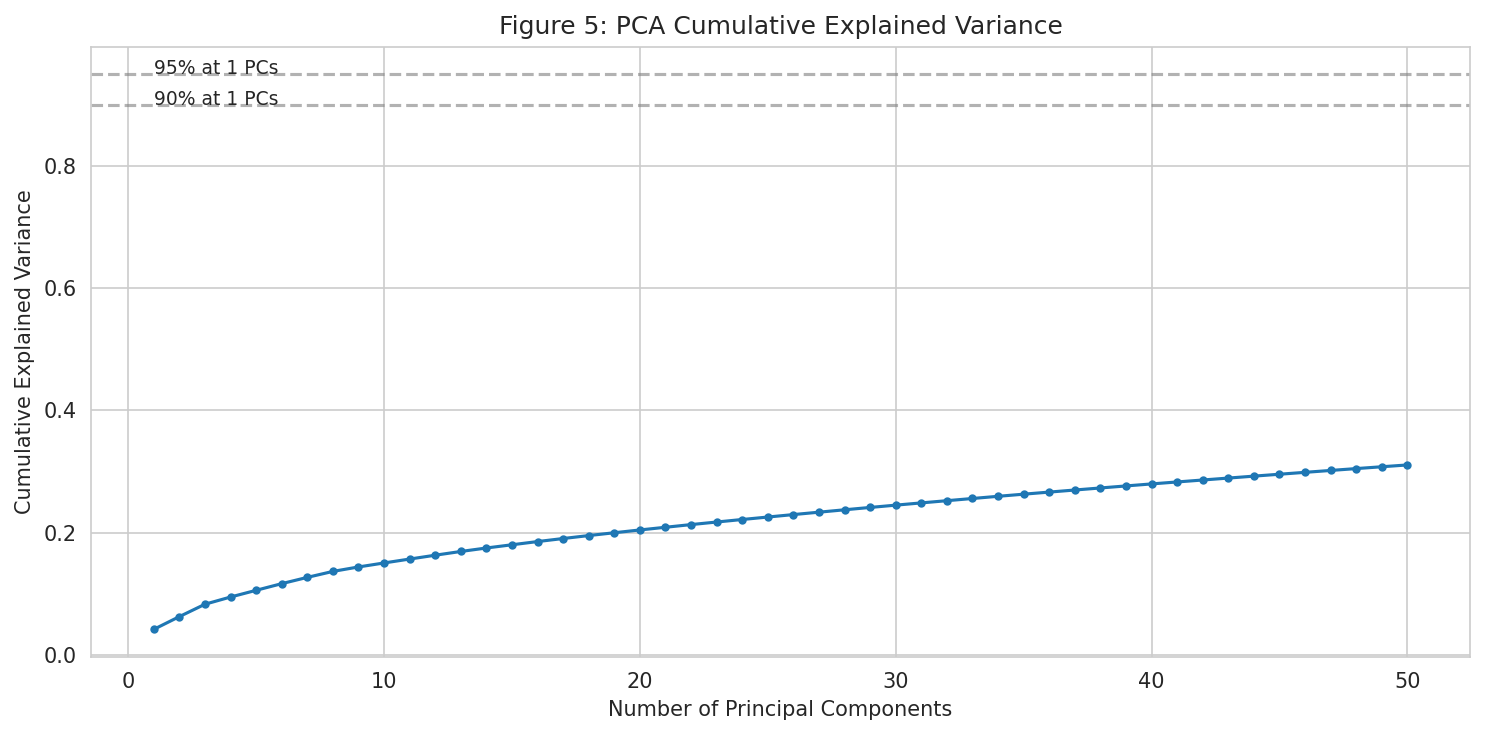

Components for 90% variance: 1
Components for 95% variance: 1
Components for 99% variance: 1


In [ ]:
# ── cumulative explained variance ──
pca_full = PCA(n_components=min(50, X_train_sc.shape[1]))
pca_full.fit(X_train_sc)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
n_99 = np.argmax(cumvar >= 0.99) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar, "o-", markersize=3)
ax.axhline(0.90, ls="--", color="gray", alpha=0.6)
ax.axhline(0.95, ls="--", color="gray", alpha=0.6)
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("Figure 5: PCA Cumulative Explained Variance")
ax.annotate(f"90% at {n_90} PCs", xy=(n_90, 0.90), fontsize=9)
ax.annotate(f"95% at {n_95} PCs", xy=(n_95, 0.95), fontsize=9)
plt.tight_layout()
plt.savefig("fig5_pca_cumvar.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")

---
## 8. Class Imbalance Analysis

In [ ]:
train_counts_only = class_distribution_df["Train Samples"]

imbalance_ratio = train_counts_only.max() / train_counts_only.min()

largest_idx = train_counts_only.idxmax()
smallest_idx = train_counts_only.idxmin()

print(f"Largest class (train) : {GESTURE_CLASSES[largest_idx]} ({train_counts_only.max()} samples)")
print(f"Smallest class (train): {GESTURE_CLASSES[smallest_idx]} ({train_counts_only.min()} samples)")
print(f"Imbalance ratio       : {imbalance_ratio:.2f}x")

if imbalance_ratio < 1.5:
    print("→ Dataset is well-balanced.")
elif imbalance_ratio < 3.0:
    print("→ Mild imbalance — weighted F1 or class_weight='balanced' recommended.")
else:
    print("→ Significant imbalance — consider oversampling / class weights.")

Largest class (train) : Clapping (1550 samples)
Smallest class (train): Clapping (1550 samples)
Imbalance ratio       : 1.00x
→ Dataset is well-balanced.


---
## 9. Raw DWT Signal Visualization (Sample Trials)

Visualize DWT coefficient patterns across channels for a few gesture classes.

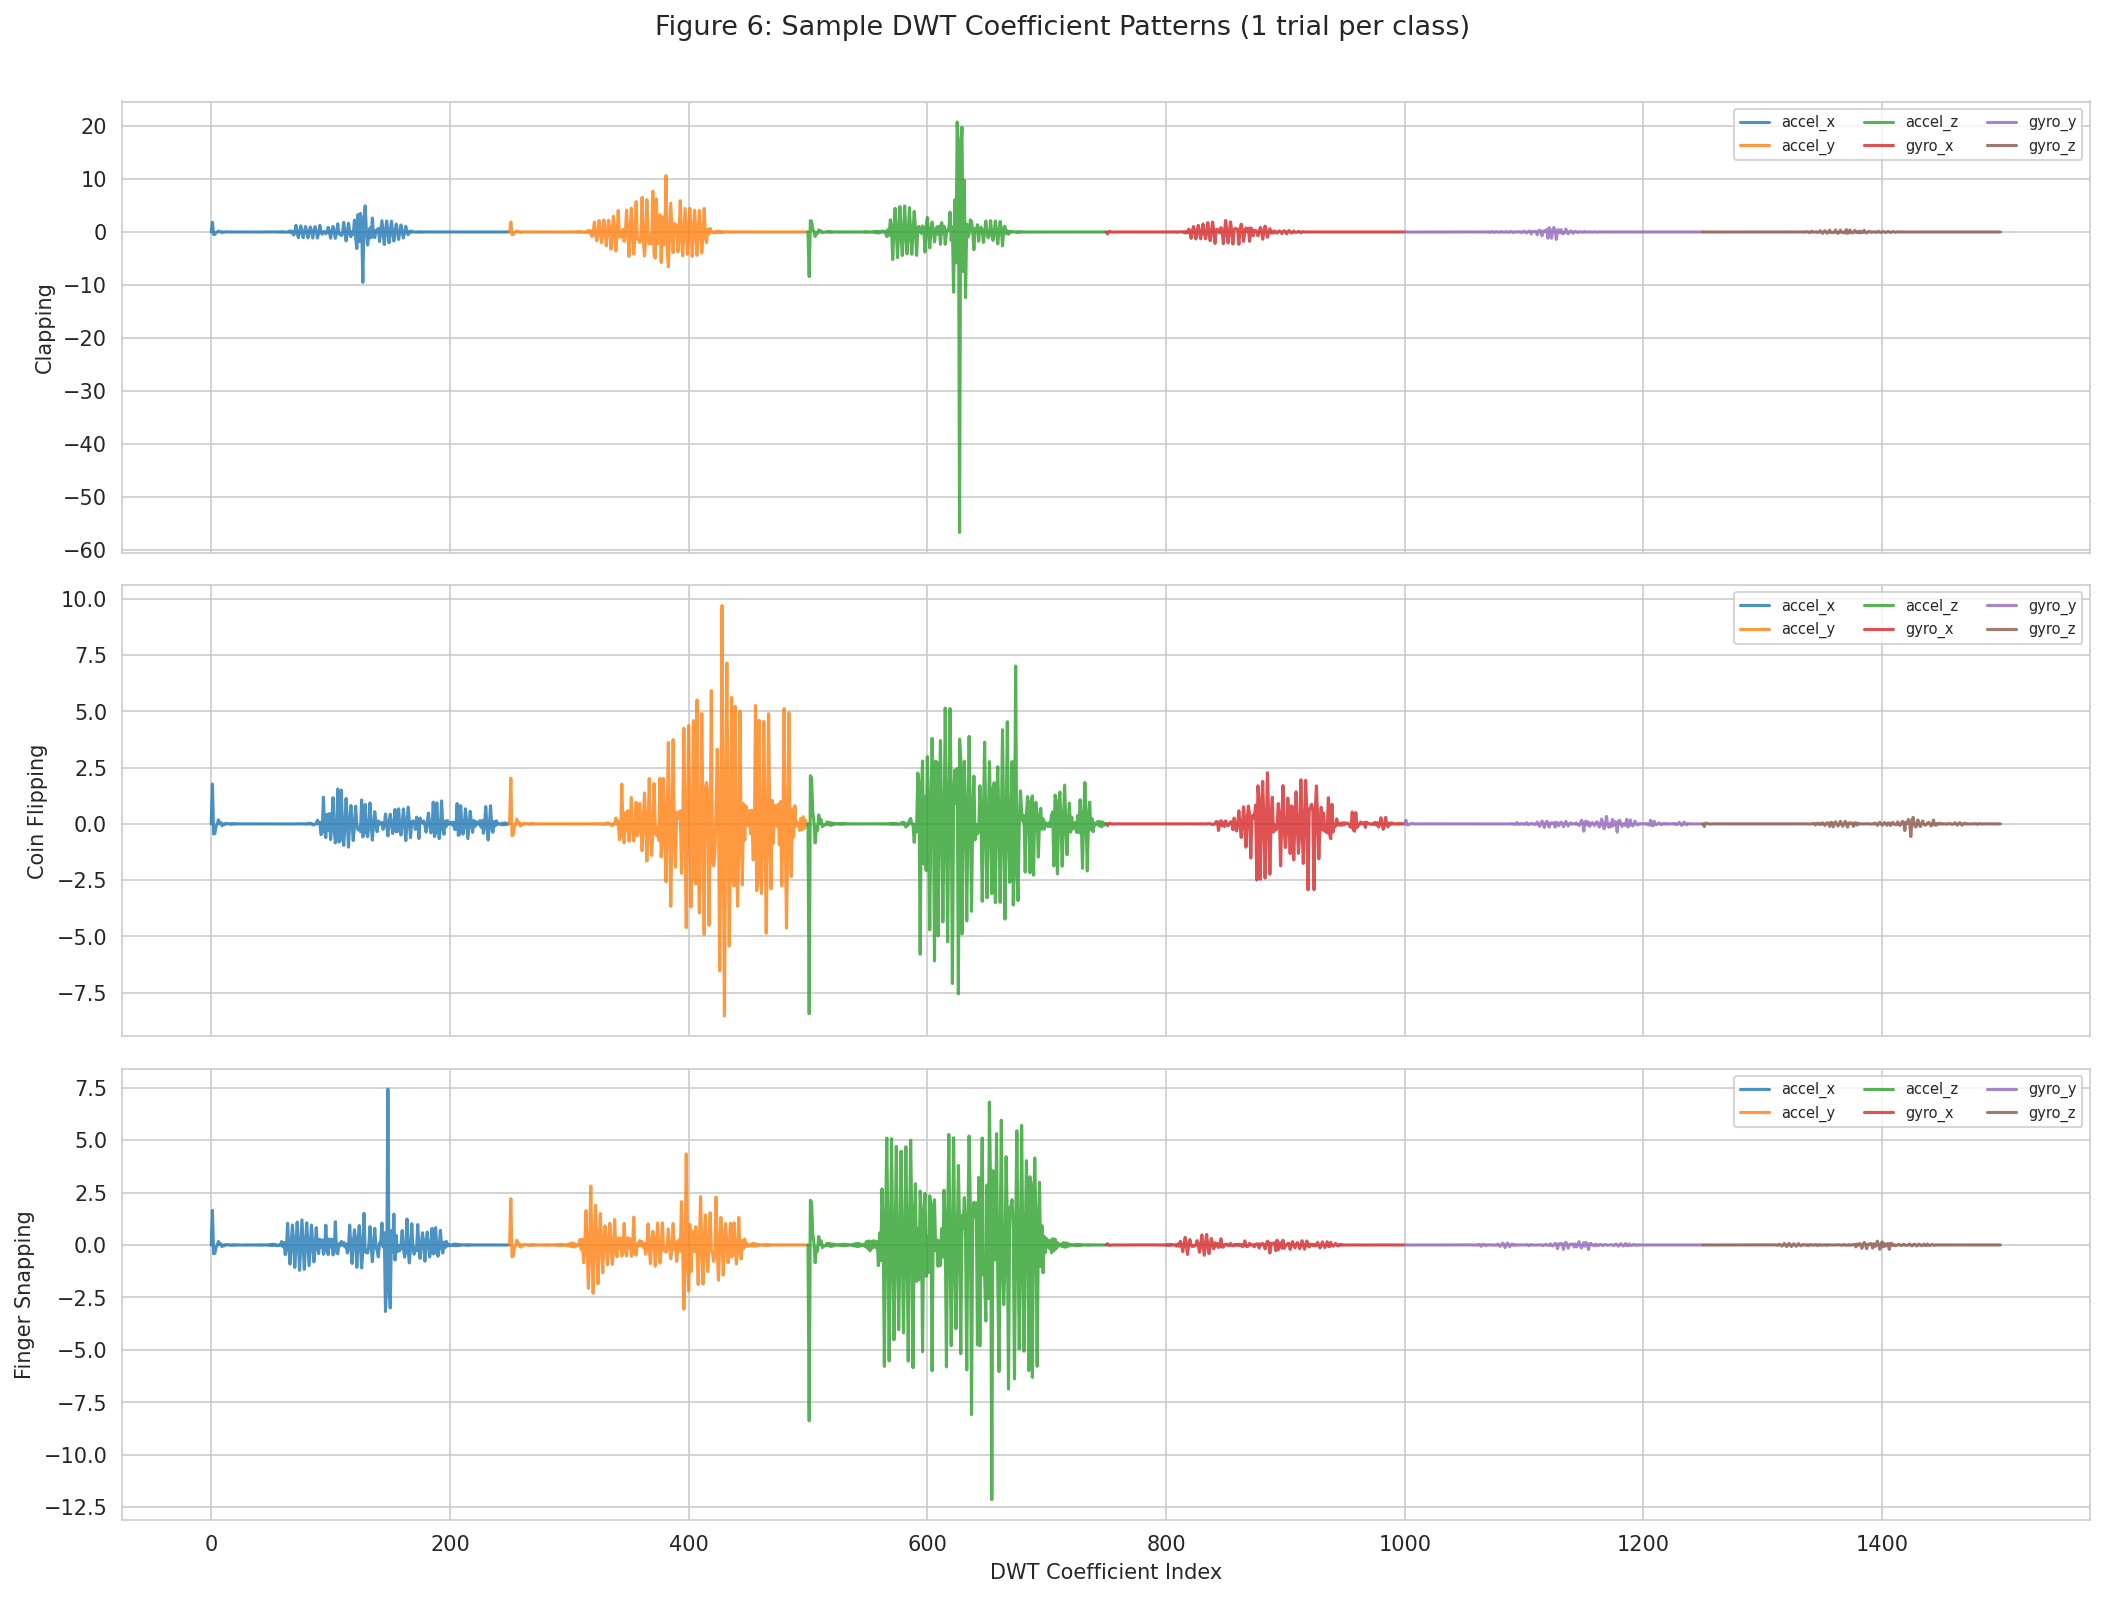

In [ ]:
# ── pick 3 sample gestures and plot 1 trial each ──
sample_gestures = GESTURE_CLASSES[:3]   # first 3 class names

fig, axes = plt.subplots(len(sample_gestures), 1, figsize=(14, 3.5 * len(sample_gestures)), sharex=True)

if len(sample_gestures) == 1:
    axes = [axes]

for row, gesture in enumerate(sample_gestures):
    class_idx = GESTURE_CLASSES.index(gesture)   # convert class name -> numeric label
    mask = (y_train == class_idx)

    if np.sum(mask) == 0:
        continue

    trial = X_train[mask][0]   # first trial of this class
    ax = axes[row]

    for ch_idx, ch in enumerate(CHANNELS):
        start = ch_idx * n_coeffs
        end = start + n_coeffs
        ax.plot(range(start, end), trial[start:end], label=ch, alpha=0.8)

    ax.set_ylabel(gesture)
    ax.legend(loc="upper right", fontsize=7, ncol=3)

axes[-1].set_xlabel("DWT Coefficient Index")
fig.suptitle("Figure 6: Sample DWT Coefficient Patterns (1 trial per class)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig6_sample_dwt_signals.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. R5 & R6 — Reproduce Baseline Results for Report

Re-train the best model from the baseline notebook and produce the exact metrics/figures needed for R5 and R6.  
We reproduce **Random Forest** (the likely best model) for self-contained reporting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

# ── same hyperparams as baseline notebook ──
rf = RandomForestClassifier(
    n_estimators=200, max_depth=30, min_samples_split=5,
    min_samples_leaf=2, max_features="sqrt", random_state=42,
    n_jobs=-1, class_weight="balanced"
)
rf.fit(X_train_sc, y_train_enc)
y_pred_rf = rf.predict(X_test_sc)

acc = accuracy_score(y_test_enc, y_pred_rf)
macro_f1 = f1_score(y_test_enc, y_pred_rf, average="macro")
weighted_f1 = f1_score(y_test_enc, y_pred_rf, average="weighted")

print(f"Random Forest — Test Set Results")
print(f"  Accuracy    : {acc:.4f}")
print(f"  Macro F1    : {macro_f1:.4f}")
print(f"  Weighted F1 : {weighted_f1:.4f}")
print(f"  Test samples: {len(y_test_enc)}")

Random Forest — Test Set Results
  Accuracy    : 0.6173
  Macro F1    : 0.6205
  Weighted F1 : 0.6205
  Test samples: 3300


In [ ]:
# ── R5: per-class precision / recall / F1 table ──
print("=" * 65)
print("PER-CLASS METRICS (copy into report R5)")
print("=" * 65)

print(classification_report(
    y_test,
    y_pred_rf,
    labels=np.arange(NUM_CLASSES),
    target_names=GESTURE_CLASSES,
    digits=4
))

PER-CLASS METRICS (copy into report R5)
                            precision    recall  f1-score   support

                  Clapping     0.5356    0.5267    0.5311       300
             Coin Flipping     0.4012    0.6833    0.5055       300
           Finger Snapping     0.4367    0.4600    0.4481       300
               Fist Making     0.4430    0.4667    0.4545       300
Horizontal Wrist Extension     0.9771    0.9967    0.9868       300
        Index Finger Flick     0.5057    0.4433    0.4725       300
           Index Thumb Tap     0.9967    1.0000    0.9983       300
                  Shooting     0.6425    0.4433    0.5247       300
                  Thumb Up     0.6870    0.5267    0.5962       300
           Wrist Extension     0.4551    0.4567    0.4559       300
             Wrist Flexion     0.9291    0.7867    0.8520       300

                  accuracy                         0.6173      3300
                 macro avg     0.6373    0.6173    0.6205      3300
      

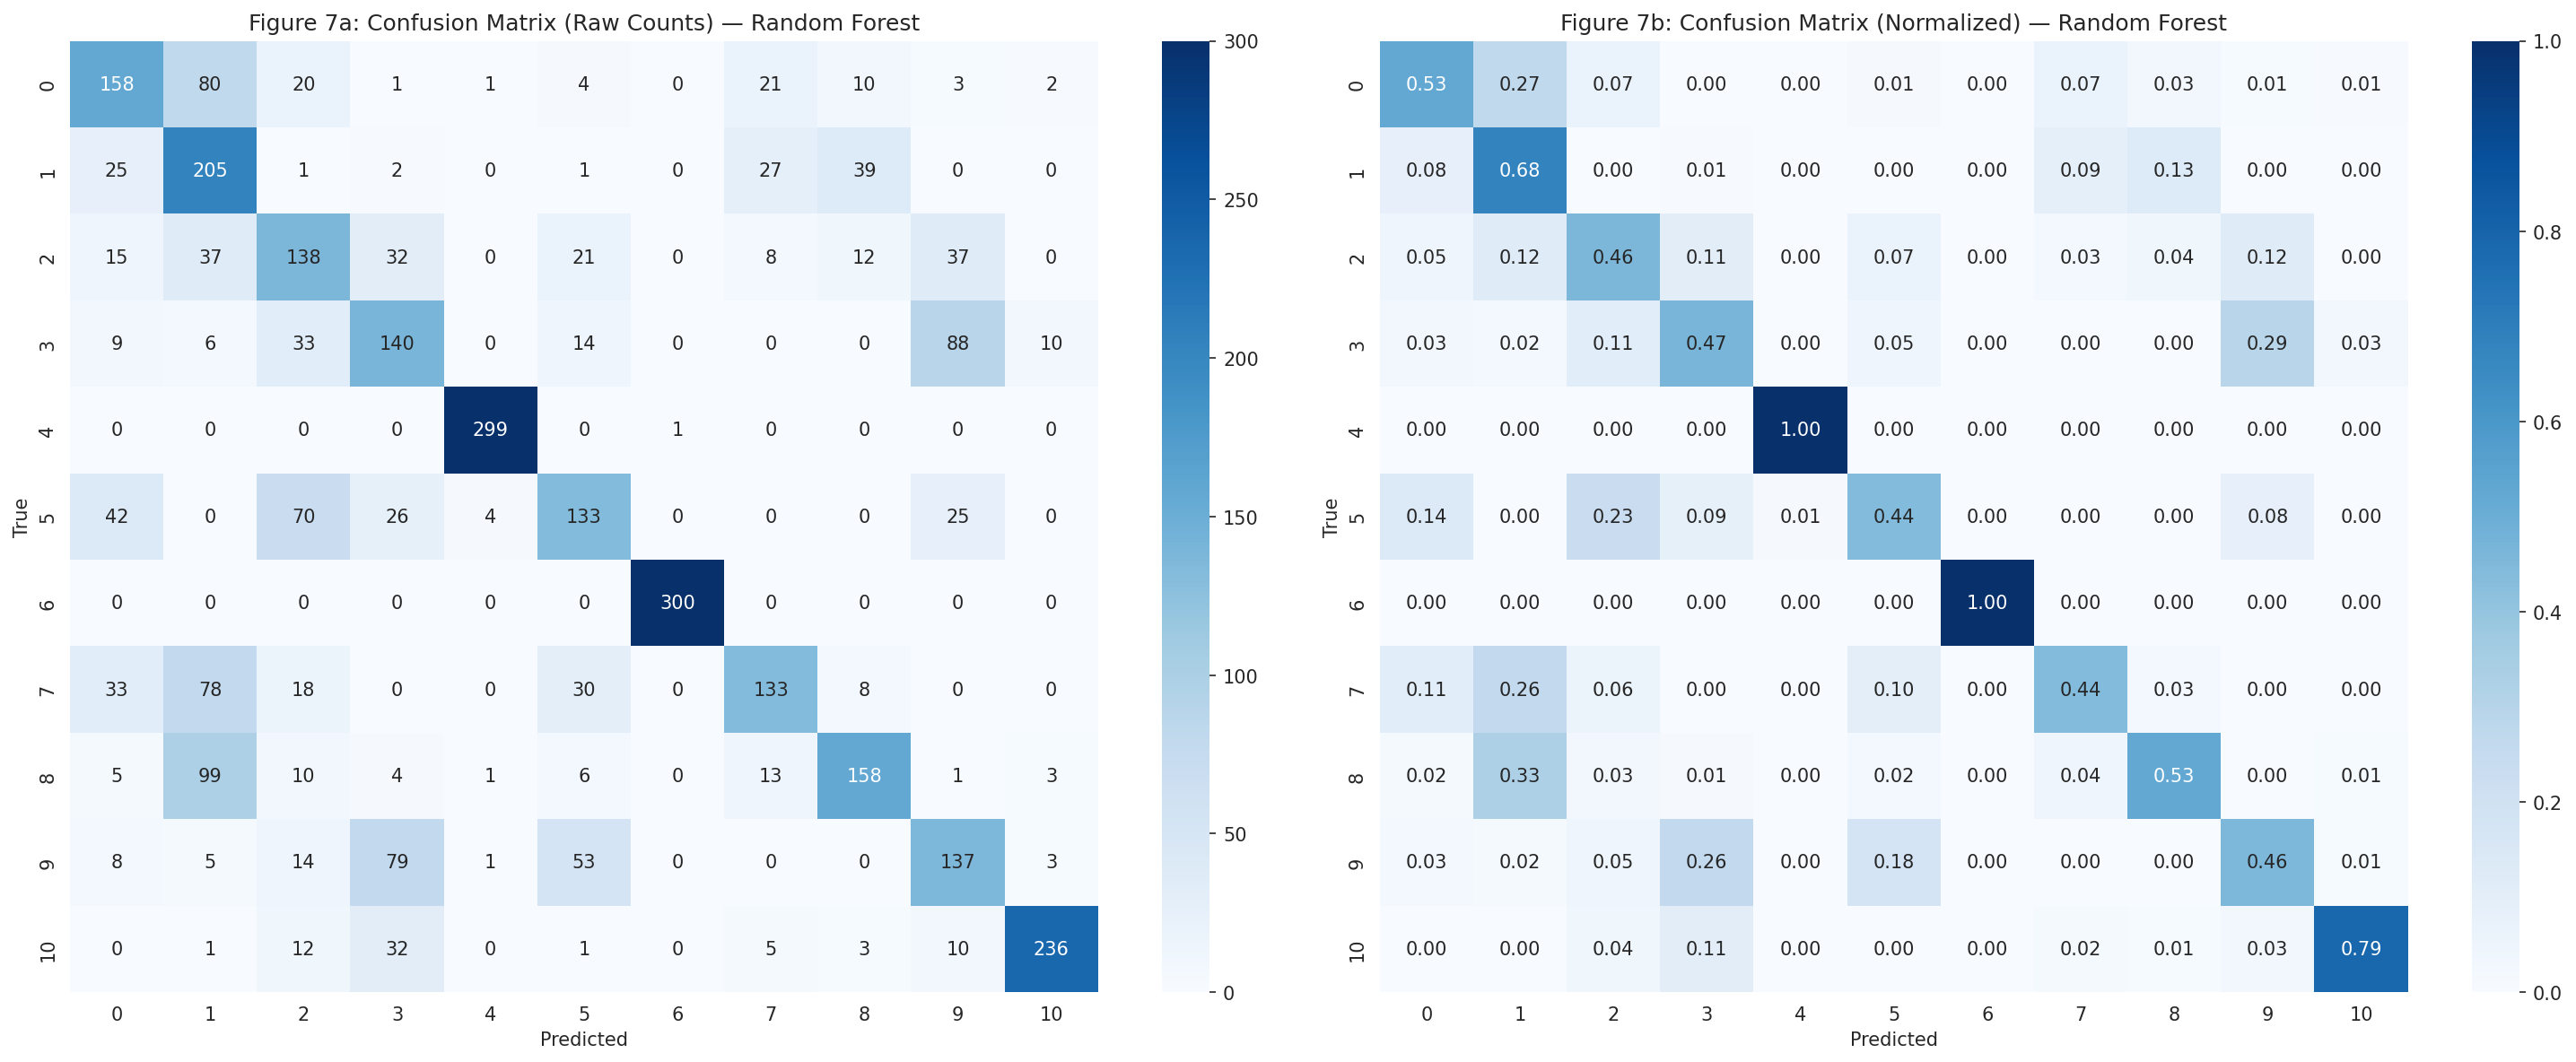

In [ ]:
# ── R5: confusion matrices (raw + normalized) ──
cm = confusion_matrix(y_test_enc, y_pred_rf)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title("Figure 7a: Confusion Matrix (Raw Counts) — Random Forest")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title("Figure 7b: Confusion Matrix (Normalized) — Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("fig7_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 11. R6 — Error Analysis

In [ ]:
# ── top confusion pairs ──
confusion_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "True": le.classes_[i],
                "Predicted": le.classes_[j],
                "Count": cm[i, j],
                "Error Rate": cm[i, j] / cm[i].sum()
            })

conf_df = pd.DataFrame(confusion_pairs).sort_values("Count", ascending=False)
print("=" * 65)
print("TOP CONFUSION PAIRS  (copy into report R6)")
print("=" * 65)
print(conf_df.head(15).to_string(index=False, float_format="{:.3f}".format))

TOP CONFUSION PAIRS  (copy into report R6)
 True  Predicted  Count  Error Rate
    8          1     99       0.330
    3          9     88       0.293
    0          1     80       0.267
    9          3     79       0.263
    7          1     78       0.260
    5          2     70       0.233
    9          5     53       0.177
    5          0     42       0.140
    1          8     39       0.130
    2          1     37       0.123
    2          9     37       0.123
    3          2     33       0.110
    7          0     33       0.110
    2          3     32       0.107
   10          3     32       0.107



PER-CLASS ACCURACY (sorted, worst first):
 Class  Accuracy
     7    0.4433
     5    0.4433
     9    0.4567
     2    0.4600
     3    0.4667
     0    0.5267
     8    0.5267
     1    0.6833
    10    0.7867
     4    0.9967
     6    1.0000


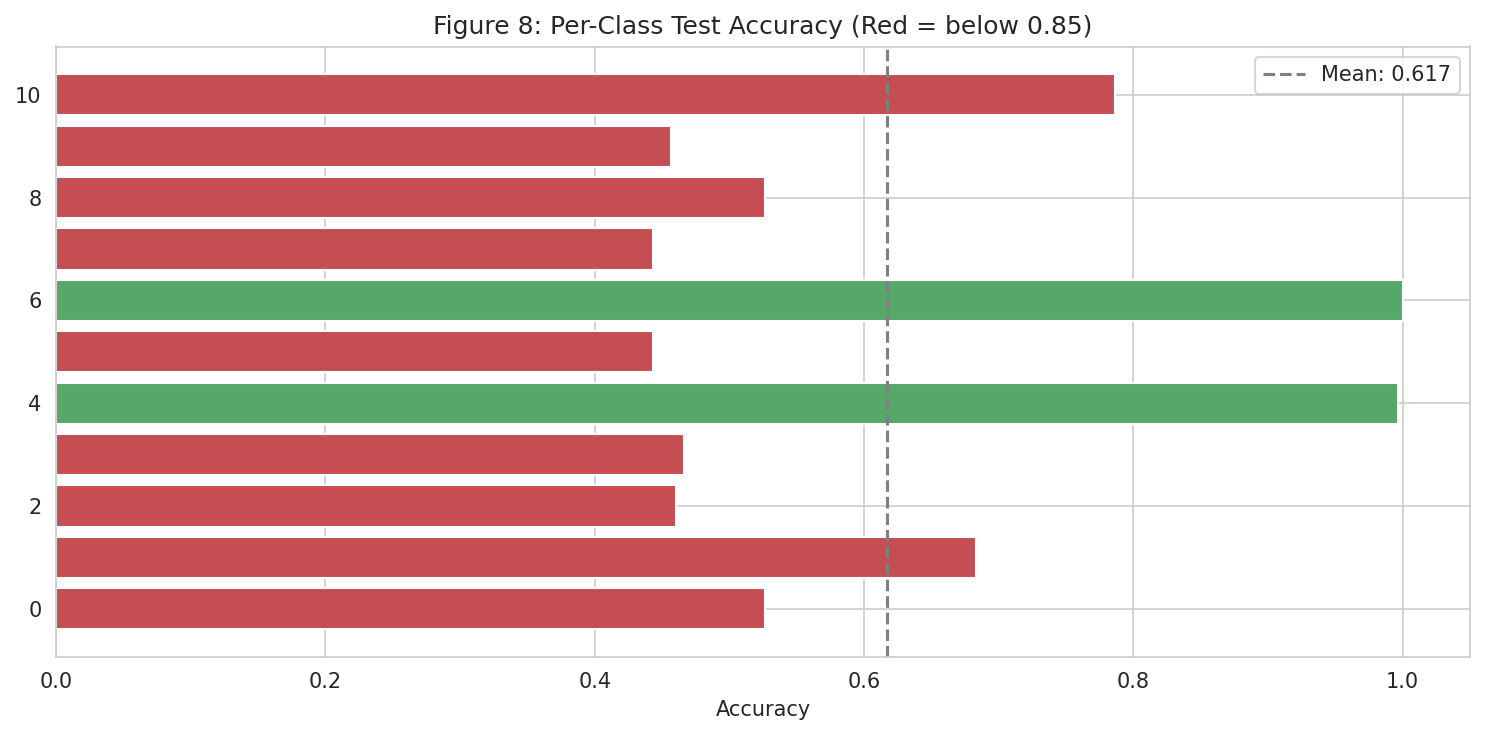

In [ ]:
# ── per-class accuracy (worst performers) ──
per_class_acc = cm.diagonal() / cm.sum(axis=1)
acc_df = pd.DataFrame({"Class": le.classes_, "Accuracy": per_class_acc})
acc_df = acc_df.sort_values("Accuracy")

print("\nPER-CLASS ACCURACY (sorted, worst first):")
print(acc_df.to_string(index=False, float_format="{:.4f}".format))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#c44e52" if a < 0.85 else "#55a868" for a in acc_df["Accuracy"]]
ax.barh(acc_df["Class"], acc_df["Accuracy"], color=colors)
ax.axvline(x=acc_df["Accuracy"].mean(), ls="--", color="gray", label=f"Mean: {acc_df['Accuracy'].mean():.3f}")
ax.set_xlabel("Accuracy")
ax.set_title("Figure 8: Per-Class Test Accuracy (Red = below 0.85)")
ax.legend()
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig("fig8_per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


FEATURE IMPORTANCE BY CHANNEL:
Channel  Mean Importance  Sum Importance
accel_x           0.0008          0.2089
accel_z           0.0008          0.2032
accel_y           0.0008          0.1942
 gyro_x           0.0006          0.1490
 gyro_y           0.0005          0.1260
 gyro_z           0.0005          0.1188


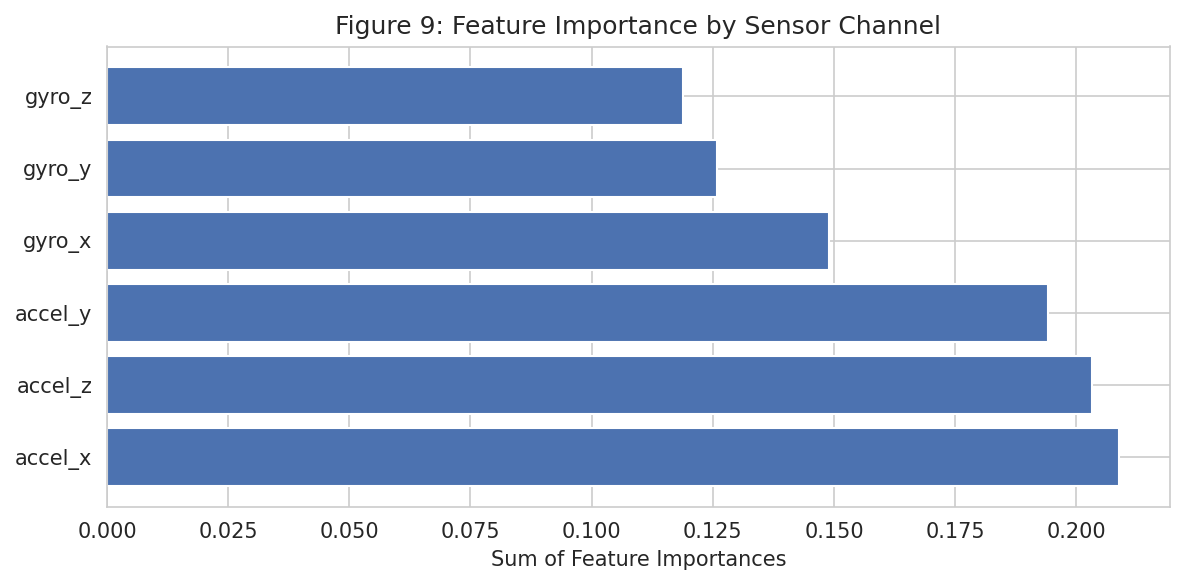

In [ ]:
# ── feature importance by channel (Random Forest) ──
importances = rf.feature_importances_
channel_importance = []
for idx, ch in enumerate(CHANNELS):
    start = idx * n_coeffs
    end   = start + n_coeffs
    channel_importance.append({
        "Channel": ch,
        "Mean Importance": importances[start:end].mean(),
        "Sum Importance":  importances[start:end].sum()
    })

imp_df = pd.DataFrame(channel_importance).sort_values("Sum Importance", ascending=False)
print("\nFEATURE IMPORTANCE BY CHANNEL:")
print(imp_df.to_string(index=False, float_format="{:.4f}".format))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_df["Channel"], imp_df["Sum Importance"], color="#4c72b0")
ax.set_xlabel("Sum of Feature Importances")
ax.set_title("Figure 9: Feature Importance by Sensor Channel")
plt.tight_layout()
plt.savefig("fig9_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 12. Missing Value & Data Quality Check

In [ ]:
print("NaN check:")
print(f"  Train: {np.isnan(X_train).sum()} NaNs")
print(f"  Val  : {np.isnan(X_val).sum()} NaNs")
print(f"  Test : {np.isnan(X_test).sum()} NaNs")

print(f"\nInf check:")
print(f"  Train: {np.isinf(X_train).sum()} Infs")
print(f"  Val  : {np.isinf(X_val).sum()} Infs")
print(f"  Test : {np.isinf(X_test).sum()} Infs")

print(f"\nDtype: {X_train.dtype}")
print(f"Feature range (train): [{X_train.min():.4f}, {X_train.max():.4f}]")

NaN check:
  Train: 0 NaNs
  Val  : 0 NaNs
  Test : 0 NaNs

Inf check:
  Train: 0 Infs
  Val  : 0 Infs
  Test : 0 Infs

Dtype: float32
Feature range (train): [-99.1566, 103.5284]


---
## 13. Summary: All Report Numbers at a Glance

Copy-paste reference for writing the PDF.

In [ ]:
print("" + "=" * 65)
print("MILESTONE 2 — REPORT NUMBERS SUMMARY")
print("=" * 65)
print(f"\nDataset: HGAG — Hand Gesture Accelerometer and Gyroscope")
print(f"Track  : B (Open/Public Dataset)")
print(f"Task   : 11-class hand gesture classification")
print(f"Classes: {', '.join(GESTURE_CLASSES)}")
print(f"\nSamples: Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}, Total={total_samples}")
print(f"Split  : ~{len(y_train)/total_samples*100:.0f}/{len(y_val)/total_samples*100:.0f}/{len(y_test)/total_samples*100:.0f} (per-subject)")
print(f"Subjects: {len(all_subjects)} total")
print(f"Features: {X_train.shape[1]} DWT coefficients (6 ch × {n_coeffs})")
print(f"Normalization: StandardScaler (train-set only)")
print(f"\n--- Baseline: Random Forest ---")
print(f"Accuracy   : {acc:.4f}")
print(f"Macro F1   : {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print(f"Test size  : {len(y_test_enc)}")
print(f"\nFigures saved:")
for f in sorted([f for f in os.listdir('.') if f.startswith('fig') and f.endswith('.png')]):
    print(f"  {f}")

MILESTONE 2 — REPORT NUMBERS SUMMARY

Dataset: HGAG — Hand Gesture Accelerometer and Gyroscope
Track  : B (Open/Public Dataset)
Task   : 11-class hand gesture classification
Classes: Clapping, Coin Flipping, Finger Snapping, Fist Making, Horizontal Wrist Extension, Index Finger Flick, Index Thumb Tap, Shooting, Thumb Up, Wrist Extension, Wrist Flexion

Samples: Train=17050, Val=3298, Test=3300, Total=23648
Split  : ~72/14/14 (per-subject)
Subjects: 43 total
Features: 1500 DWT coefficients (6 ch × 250)
Normalization: StandardScaler (train-set only)

--- Baseline: Random Forest ---
Accuracy   : 0.6173
Macro F1   : 0.6205
Weighted F1: 0.6205
Test size  : 3300

Figures saved:
  fig1_class_distribution.png
  fig2_channel_boxplots.png
  fig3_channel_correlation.png
  fig4_pca_scatter.png
  fig5_pca_cumvar.png
  fig6_sample_dwt_signals.png
  fig7_confusion_matrix.png
  fig8_per_class_accuracy.png
  fig9_feature_importance.png
